Grupo: Matheus Braga, Diogo Nogueira, Ana Isabela e Marco Andrade

**Projeto de otimização utilizando Hill Climb e Algoritmo Genético**

O problema modela um currículo acadêmico de um curso de ensino superior — mais especificamente, ele representa como as disciplinas desse curso podem ser distribuídas ao longo de um certo número de períodos (como semestres ou anos), levando em consideração diversas restrições pedagógicas e administrativas. Podemos persar que o objetivo do modelo é distribuir essas disciplinas em “baldes” temporais (os semestres ou anos) de modo que todas as regras pedagógicas e organizacionais sejam respeitadas.

**Detalhes da modelagem do problema:**

-Cada entrada no dataset representa uma disciplina que deve obrigatóriamente ser cursada. Cada disciplina é discriminada por seu código, carga horária e pré requisito (caso se aplique).

-O objetivo é alocar todas as disciplinas de modo que os períodos fiquem o mais equilibrados possíveis no critério de carga horária.

-O sistema impõe restrições, como numero
de períodos, mínimo e máximo de horas por período, mínimo e máximo de disciplinas por período.

-Como já foi abordado, algumas disciplinas possuem pré requisitos e só podem ser cursadas caso seus pré requisitos sejam cumpridos anteriormente.

-Função Custo: Como usamos a função buscando minimização, usamos a função custo, poderiamos converter em função fitness basicamente usando 1/(1+custo) ou até -1*custo, mas preferimos nesse problema manter como custo para facilitar a vizualização e análise dos dados pós resolução. Função essa que mede o quão boa é a solução. Horas por período e quantidade de discplinas por período fora do intervalo pré estabelecido geram uma penalidade alta. Horas desbalanceadas por período tambem geram penalização.

# Pré definições

## 1. Imports e parametros

In [ ]:
import random
import matplotlib.pyplot as plt
import statistics

num_periods = 8  # Número de períodos (slots)
min_hours_per_period = 10  # Horas mínimas permitidas por período
max_hours_per_period = 24  # Horas máximas permitidas por período
min_classes_per_period = 2  # Mínimo de cursos por período
max_classes_per_period = 10  # Máximo de cursos por período

## 2. Dados da Instância

In [ ]:
courses = [
    "dew100",
    "fis100",
    "hcw310",
    "iwg101",
    "mat190",
    "mat192",
    "dew101",
    "fis101",
    "iwi131",
    "mat191",
    "mat193",
    "fis102",
    "hxwxx1",
    "iei134",
    "iei141",
    "mat194",
    "dewxx0",
    "hcw311",
    "iei132",
    "iei133",
    "iei142",
    "iei162",
    "iwn170",
    "mat195",
    "hxwxx2",
    "iei231",
    "iei241",
    "iei271",
    "iei281",
    "iwn261",
    "hfw120",
    "iei233",
    "iei238",
    "iei261",
    "iei272",
    "iei273",
    "iei161",
    "iei232",
    "iei262",
    "iei274",
    "iwi365",
    "iwn270",
    "hrw130",
    "iei218",
    "iei219",
    "iei248",
]

course_hours = [
    1,
    3,
    1,
    2,
    4,
    4,
    1,
    5,
    3,
    4,
    4,
    5,
    1,
    3,
    3,
    4,
    1,
    1,
    3,
    3,
    3,
    3,
    3,
    3,
    1,
    4,
    4,
    3,
    3,
    3,
    2,
    4,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    2,
    3,
    3,
    3,
]

prereqs = [
    ("dew101", "dew100"),
    ("fis101", "fis100"),
    ("fis101", "mat192"),
    ("mat191", "mat190"),
    ("mat193", "mat190"),
    ("mat193", "mat192"),
    ("fis102", "fis101"),
    ("fis102", "mat193"),
    ("iei134", "iwi131"),
    ("iei141", "iwi131"),
    ("mat194", "mat191"),
    ("mat194", "mat193"),
    ("dewxx0", "dew101"),
    ("hcw311", "hcw310"),
    ("iei132", "iei134"),
    ("iei133", "iei134"),
    ("iei142", "iei141"),
    ("mat195", "mat194"),
    ("iei231", "iei134"),
    ("iei241", "iei142"),
    ("iei271", "iei162"),
    ("iei281", "mat195"),
    ("iei233", "iei231"),
    ("iei238", "iei231"),
    ("iei261", "iwn261"),
    ("iei272", "iei271"),
    ("iei273", "iei271"),
    ("iei161", "iwn261"),
    ("iei232", "iei273"),
    ("iei262", "iwn261"),
    ("iei274", "iei273"),
    ("iei219", "iei232"),
    ("iei248", "iei233"),
]

#Hill Climb

## 3. Avaliação de Soluções

In [ ]:
# 1. Mapeamento de curso para índice
course_to_index = {course: idx for idx, course in enumerate(courses)}


# 2. Função de custo
def calculate_schedule_cost(schedule):
    hours_per_period = [0] * num_periods
    classes_per_period = [0] * num_periods
    for idx_course, period in enumerate(schedule):
        period_idx = period - 1
        hours_per_period[period_idx] += course_hours[idx_course]
        classes_per_period[period_idx] += 1

    cost = statistics.pvariance(hours_per_period)
    penalty_factor = max(course_hours) * len(courses)

    for i in range(num_periods):
        if hours_per_period[i] < min_hours_per_period:
            cost += penalty_factor * (min_hours_per_period - hours_per_period[i])
        if hours_per_period[i] > max_hours_per_period:
            cost += penalty_factor * (hours_per_period[i] - max_hours_per_period)
        if classes_per_period[i] < min_classes_per_period:
            cost += penalty_factor * (min_classes_per_period - classes_per_period[i])
        if classes_per_period[i] > max_classes_per_period:
            cost += penalty_factor * (classes_per_period[i] - max_classes_per_period)

    for course, pre in prereqs:
        if schedule[course_to_index[course]] <= schedule[course_to_index[pre]]:
            cost += penalty_factor

    return cost


# 3. Geração de solução inicial
def generate_initial_schedule(seed):
    random.seed(seed)
    return [random.randint(1, num_periods) for _ in courses]


# 4. Operadores de vizinhança
def neighbor_reassign(schedule):
    new_schedule = schedule.copy()
    i = random.randrange(len(courses))
    new_schedule[i] = random.randint(1, num_periods)
    return new_schedule


def neighbor_swap(schedule):
    new_schedule = schedule.copy()
    i, j = random.sample(range(len(courses)), 2)
    new_schedule[i], new_schedule[j] = new_schedule[j], new_schedule[i]
    return new_schedule

##4. Hill Climbing

In [ ]:

# 5. Hill Climbing
def hill_climbing_search(max_iterations=10000, seed=42):
    current = generate_initial_schedule(seed)
    best = current[:]
    best_cost = calculate_schedule_cost(current)
    history = [best_cost]

    for _ in range(max_iterations):
        if random.random() < 0.5:
            candidate = current
        else:
            candidate = neighbor_swap(current)
        cand_cost = calculate_schedule_cost(candidate)
        if cand_cost < best_cost:
            current = candidate[:]
            best = candidate[:]
            best_cost = cand_cost
        history.append(best_cost)

    return best, best_cost, history


##5. Checagem de possíveis violações

In [ ]:
# Função para checar violações de regras em um cronograma (schedule)
def check_violations(schedule):
    """
    Retorna uma lista de strings descrevendo quais regras foram violadas pelo schedule.
    Regras:
      - Horas por período fora dos limites [min_hours_per_period, max_hours_per_period]
      - Número de cursos por período fora dos limites [min_classes_per_period, max_classes_per_period]
      - Pré-requisitos violados: curso alocado em mesmo ou período anterior ao seu pré-requisito
    """
    violations = []

    # 1. Verificar horas e quantidade de cursos por período
    hours_per_period = [0] * num_periods
    classes_per_period = [0] * num_periods
    for idx_course, period in enumerate(schedule):
        idx_period = period - 1
        hours_per_period[idx_period] += course_hours[idx_course]
        classes_per_period[idx_period] += 1

    for i in range(num_periods):
        # Checar horas mínimas
        if hours_per_period[i] < min_hours_per_period:
            violations.append(
                f"Período {i+1}: apenas {hours_per_period[i]} horas "
                f"(mínimo exigido = {min_hours_per_period})"
            )
        # Checar horas máximas
        if hours_per_period[i] > max_hours_per_period:
            violations.append(
                f"Período {i+1}: {hours_per_period[i]} horas "
                f"(máximo permitido = {max_hours_per_period})"
            )
        # Checar número de cursos mínimos
        if classes_per_period[i] < min_classes_per_period:
            violations.append(
                f"Período {i+1}: apenas {classes_per_period[i]} cursos "
                f"(mínimo exigido = {min_classes_per_period})"
            )
        # Checar número de cursos máximos
        if classes_per_period[i] > max_classes_per_period:
            violations.append(
                f"Período {i+1}: {classes_per_period[i]} cursos "
                f"(máximo permitido = {max_classes_per_period})"
            )

    # 2. Verificar pré-requisitos
    for course, prereq_course in prereqs:
        idx_course = course_to_index[course]
        idx_prereq = course_to_index[prereq_course]
        if schedule[idx_course] <= schedule[idx_prereq]:
            violations.append(
                f"Pré-requisito violado: curso '{course}' "
                f"(período {schedule[idx_course]}) precisa vir após "
                f"'{prereq_course}' (período {schedule[idx_prereq]})"
            )

    return violations

##6. Executa o Hill Climbing em diferentes seeds
Pois o algoritmo começa de um ponto X qualquer, podendo ficar preso a um mínimo local. Executando runs em seeds diferentes, ele tende a achar pontos mais altos.


In [ ]:
# ----------------------------
# 5. Executa o HC para 15 seeds diferentes
# ----------------------------
base_seed = 42
num_runs = 15
num_generations = 100

seeds = [base_seed + i for i in range(num_runs)]
results = []  # (seed, best_cost, best_schedule)

for seed in seeds:
    schedule, cost, histor = hill_climbing_search(
        max_iterations=max_iterations, seed=seed
    )
    results.append((seed, cost, schedule))

# 5.1 Identifica o melhor global entre todos os seeds
best_seed, best_cost_global, best_schedule_global = min(results, key=lambda x: x[1])

# 5.2 Imprime resultado global
print(f"Melhor custo global: {best_cost_global:.6f}  (seed {best_seed})\n")

# 4. Verificar e imprimir violações para essa melhor solução
violations = check_violations(best_schedule_global)
print("\nRegras violadas por esta solução (se houver):")
if not violations:
    print("  Nenhuma violação detectada. Todos os requisitos estão satisfeitos.")
else:
    for v in violations:
        print("  -", v)

print()
print("Solução (curso -> período) para o melhor custo global:")
for course, period in zip(courses, best_schedule_global):
    print(f"  {course}: {period}")

##7. Solução e Plotagem do Gráfico

Melhor custo global: 462.484375  (seed 46)


Regras violadas por esta solução (se houver):
  - Pré-requisito violado: curso 'iei271' (período 1) precisa vir após 'iei162' (período 3)
  - Pré-requisito violado: curso 'iei281' (período 6) precisa vir após 'mat195' (período 8)

Solução (curso -> período) para o melhor custo global:
  dew100: 2
  fis100: 3
  hcw310: 2
  iwg101: 2
  mat190: 3
  mat192: 1
  dew101: 6
  fis101: 4
  iwi131: 1
  mat191: 6
  mat193: 4
  fis102: 5
  hxwxx1: 6
  iei134: 2
  iei141: 2
  mat194: 7
  dewxx0: 8
  hcw311: 6
  iei132: 8
  iei133: 8
  iei142: 5
  iei162: 3
  iwn170: 8
  mat195: 8
  hxwxx2: 2
  iei231: 3
  iei241: 7
  iei271: 1
  iei281: 6
  iwn261: 3
  hfw120: 2
  iei233: 5
  iei238: 7
  iei261: 6
  iei272: 2
  iei273: 4
  iei161: 4
  iei232: 6
  iei262: 5
  iei274: 7
  iwi365: 8
  iwn270: 2
  hrw130: 1
  iei218: 1
  iei219: 7
  iei248: 6


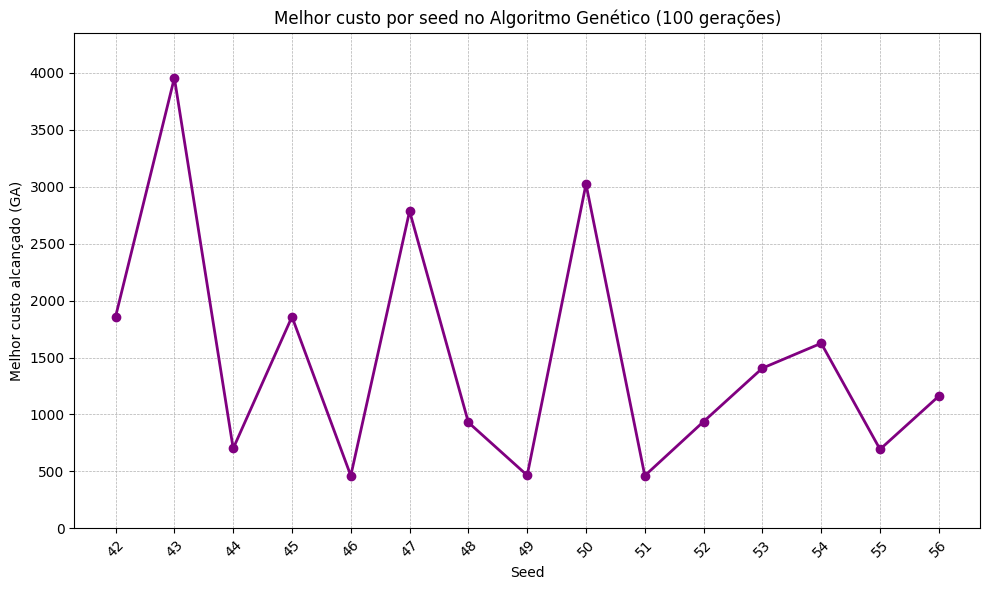

In [ ]:
# 5.3 Plota melhor custo de cada seed em gráfico de linhas
best_costs = [cost for (_, cost, _) in results]

plt.figure(figsize=(10, 6))
plt.plot(seeds, best_costs, marker="o", linestyle="-", linewidth=2, color="purple")
plt.xlabel("Seed")
plt.ylabel("Melhor custo alcançado (GA)")
plt.title(f"Melhor custo por seed no Algoritmo Genético ({num_generations} gerações)")
plt.xticks(seeds, rotation=45)
plt.ylim(0, max(best_costs) * 1.1)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


#Algoritmo Genético

## 1. Hiperparametros

In [ ]:
def genetic_search(
    pop_size=50, num_generations=100, crossover_rate=0.8, mutation_rate=0.1, seed=42
):
    random.seed(seed)

##2. População e custo inicial


In [ ]:
    # 1.Cria a população inicial
    population = [
        [random.randint(1, num_periods) for _ in courses] for _ in range(pop_size)
    ]
    # Avalia o custo inicial
    costs = [calculate_schedule_cost(ind) for ind in population]

    best_history = []

##3. Algoritmo genético

In [ ]:
    for gen in range(num_generations):
        # Mantém o melhor individuo (elitismo)
        best_idx = min(range(pop_size), key=lambda i: costs[i])
        best_history.append(costs[best_idx])
        new_population = [population[best_idx][:]]

        # 2. Gera novos individuos
        while len(new_population) < pop_size:
            # Selecão ("torneio")
            def tournament_select():
                competitors = random.sample(range(pop_size), 3)
                return min(competitors, key=lambda i: costs[i])

            pai_1 = population[tournament_select()]
            pai_2 = population[tournament_select()]

            # Crossover
            if random.random() < crossover_rate:
                point = random.randrange(1, len(courses))
                child1 = pai_1[:point] + pai_2[point:]
                child2 = pai_2[:point] + pai_1[point:]
            else:
                child1, child2 = pai_1[:], pai_2[:]

            # Mutação
            def mutate(ind):
                for i in range(len(ind)):
                    if random.random() < mutation_rate:
                        ind[i] = random.randint(1, num_periods)
                return ind

            new_population.append(mutate(child1))
            if len(new_population) < pop_size:
                new_population.append(mutate(child2))

        # Atualiza custos e a população
        population = new_population
        costs = [calculate_schedule_cost(ind) for ind in population]

    # Melhor Final
    best_idx = min(range(pop_size), key=lambda i: costs[i])
    best_schedule = population[best_idx]
    best_cost = costs[best_idx]

    return best_schedule, best_cost, best_history

##4. Executa o Algoritmo Genético em diferentes seeds
Pois o algoritmo começa de um ponto X qualquer, podendo ficar preso a um mínimo local. Executando runs em seeds diferentes, ele tende a achar pontos mais altos.

In [ ]:

# ----------------------------
# 5. Executa o GA para 15 seeds diferentes
# ----------------------------
base_seed = 42
num_runs = 15
num_generations = 100

seeds = [base_seed + i for i in range(num_runs)]
results = []  # (seed, best_cost, best_schedule)

for seed in seeds:
    schedule, cost, history = genetic_search(
        pop_size=50,
        num_generations=num_generations,
        crossover_rate=0.8,
        mutation_rate=0.1,
        seed=seed,
    )
    results.append((seed, cost, schedule))

# 5.1 Identifica o melhor global entre todos os seeds
best_seed, best_cost_global, best_schedule_global = min(results, key=lambda x: x[1])

# 5.2 Imprime resultado global
print(f"Melhor custo global: {best_cost_global:.6f}  (seed {best_seed})\n")

# 4. Verificar e imprimir violações para essa melhor solução
violations = check_violations(best_schedule_global)
print("\nRegras violadas por esta solução (se houver):")
if not violations:
    print("  Nenhuma violação detectada. Todos os requisitos estão satisfeitos.")
else:
    for v in violations:
        print("  -", v)

print("Solução (curso -> período) para o melhor custo global:")
for course, period in zip(courses, best_schedule_global):
    print(f"  {course}: {period}")

##5. Solução e Plotagem do Gráfico

Melhor custo global: 462.484375  (seed 51)


Regras violadas por esta solução (se houver):
  - Pré-requisito violado: curso 'iei271' (período 1) precisa vir após 'iei162' (período 8)
  - Pré-requisito violado: curso 'iei281' (período 3) precisa vir após 'mat195' (período 6)
Solução (curso -> período) para o melhor custo global:
  dew100: 2
  fis100: 4
  hcw310: 3
  iwg101: 7
  mat190: 1
  mat192: 2
  dew101: 5
  fis101: 5
  iwi131: 1
  mat191: 4
  mat193: 3
  fis102: 6
  hxwxx1: 7
  iei134: 2
  iei141: 4
  mat194: 5
  dewxx0: 8
  hcw311: 8
  iei132: 4
  iei133: 5
  iei142: 5
  iei162: 8
  iwn170: 2
  mat195: 6
  hxwxx2: 3
  iei231: 3
  iei241: 7
  iei271: 1
  iei281: 3
  iwn261: 1
  hfw120: 4
  iei233: 4
  iei238: 7
  iei261: 7
  iei272: 2
  iei273: 2
  iei161: 8
  iei232: 3
  iei262: 8
  iei274: 7
  iwi365: 5
  iwn270: 8
  hrw130: 8
  iei218: 1
  iei219: 6
  iei248: 6


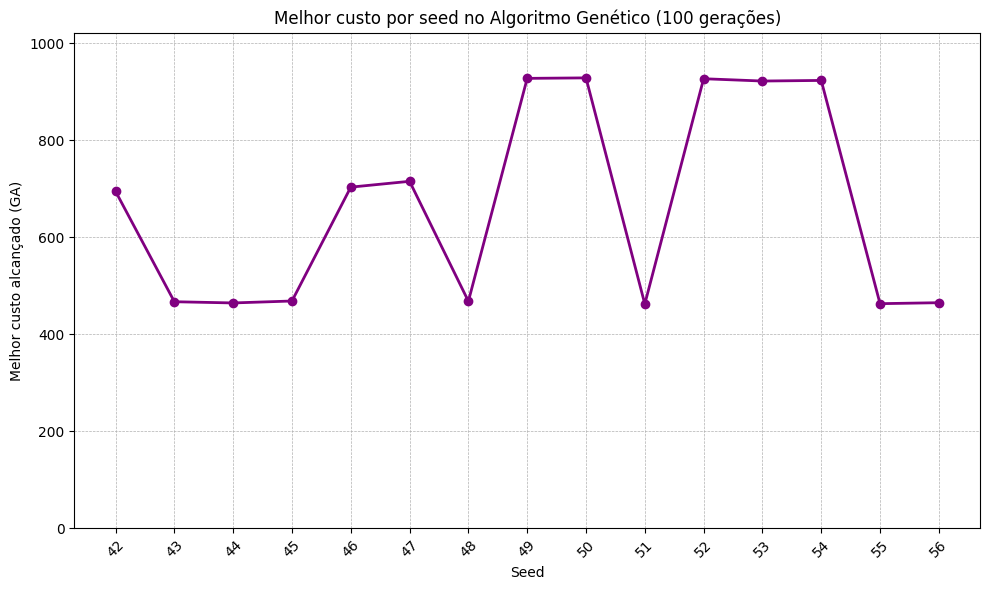

In [ ]:
# 5.3 Plota melhor custo de cada seed em gráfico de linhas
best_costs = [cost for (_, cost, _) in results]

plt.figure(figsize=(10, 6))
plt.plot(seeds, best_costs, marker="o", linestyle="-", linewidth=2, color="purple")
plt.xlabel("Seed")
plt.ylabel("Melhor custo alcançado (GA)")
plt.title(f"Melhor custo por seed no Algoritmo Genético ({num_generations} gerações)")
plt.xticks(seeds, rotation=45)
plt.ylim(0, max(best_costs) * 1.1)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


## 6. Variação nos Parametros para achar a configuração ideal

Melhor custo global: 231.484375

Regras violadas por esta solução (se houver):
  - Pré-requisito violado: curso 'iei271' (período 1) precisa vir após 'iei162' (período 8)
  - Pré-requisito violado: curso 'iei281' (período 3) precisa vir após 'mat195' (período 6)

Configuração que gerou esse melhor custo:
  pop_size=20, num_generations=200, crossover_rate=0.6
Solução (curso -> período) para esse melhor custo:
  dew100: 1
  fis100: 1
  hcw310: 5
  iwg101: 1
  mat190: 2
  mat192: 3
  dew101: 7
  fis101: 6
  iwi131: 1
  mat191: 5
  mat193: 4
  fis102: 8
  hxwxx1: 2
  iei134: 2
  iei141: 2
  mat194: 6
  dewxx0: 8
  hcw311: 6
  iei132: 7
  iei133: 6
  iei142: 5
  iei162: 1
  iwn170: 3
  mat195: 1
  hxwxx2: 2
  iei231: 3
  iei241: 7
  iei271: 2
  iei281: 4
  iwn261: 3
  hfw120: 2
  iei233: 4
  iei238: 4
  iei261: 5
  iei272: 8
  iei273: 4
  iei161: 6
  iei232: 6
  iei262: 8
  iei274: 8
  iwi365: 7
  iwn270: 3
  hrw130: 5
  iei218: 7
  iei219: 7
  iei248: 5


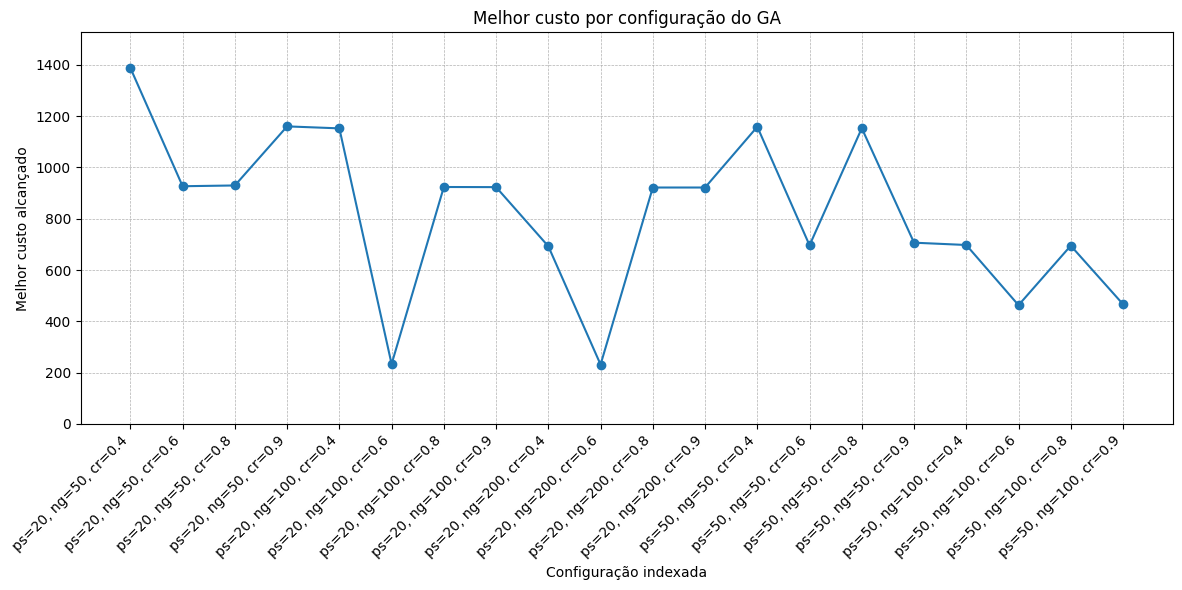

In [ ]:

# 2. Configurações a variar: pop_size, num_generations, crossover_rate
pop_sizes = [20, 50, 100]
num_gens = [50, 100, 200]
crossover_rates = [0.4, 0.6, 0.8, 0.9]

# Gerar 15 combinações (tomando primeiro 15 do produto cartesiano)
configs = []
for ps in pop_sizes:
    for ng in num_gens:
        for cr in crossover_rates:
            configs.append((ps, ng, cr))
            if len(configs) == 20:
                break
        if len(configs) == 20:
            break
    if len(configs) == 20:
        break

# 3. Executar GA para cada configuração (seed fixo, p.ex. 42)
results = []
for ps, ng, cr in configs:
    schedule, cost, history = genetic_search(
        pop_size=ps,
        num_generations=ng,
        crossover_rate=cr,
        mutation_rate=0.1,
        seed=42,  # mesma seed para comparação consistente
    )
    results.append(
        {
            "pop_size": ps,
            "num_generations": ng,
            "crossover_rate": cr,
            "best_cost": cost,
            "best_schedule": schedule,
        }
    )

# 4. Identificar melhor custo global
best_config = min(results, key=lambda r: r["best_cost"])

# 5. Imprimir melhor global
print(f"Melhor custo global: {best_config['best_cost']:.6f}")

# 4. Verificar e imprimir violações para essa melhor solução
violations = check_violations(best_schedule_global)
print("\nRegras violadas por esta solução (se houver):")
if not violations:
    print("  Nenhuma violação detectada. Todos os requisitos estão satisfeitos.")
else:
    for v in violations:
        print("  -", v)

print()
print("Configuração que gerou esse melhor custo:")
print(
    f"  pop_size={best_config['pop_size']}, num_generations={best_config['num_generations']}, crossover_rate={best_config['crossover_rate']}"
)
print("Solução (curso -> período) para esse melhor custo:")
for course, period in zip(courses, best_config["best_schedule"]):
    print(f"  {course}: {period}")

# 6. Plotar melhores custos de cada configuração
labels = [
    f"ps={r['pop_size']}, ng={r['num_generations']}, cr={r['crossover_rate']}"
    for r in results
]
best_costs = [r["best_cost"] for r in results]

plt.figure(figsize=(12, 6))
plt.plot(range(len(results)), best_costs, marker="o", linestyle="-")
plt.xticks(range(len(results)), labels, rotation=45, ha="right")
plt.xlabel("Configuração indexada")
plt.ylabel("Melhor custo alcançado")
plt.title("Melhor custo por configuração do GA")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.ylim(0, max(best_costs) * 1.1)
plt.tight_layout()
plt.show()
